In [ ]:
# 导入基础库
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# 固定随机种子
np.random.seed(42)

# 环境参数
config = {
    "space": (26.0, 14.0),
    "station": np.array([23.0, 4.5]),
    "station_radius": 1.0,
    "charge_power": 0.030,

    "start_mean": np.array([4.0, 10.0]),
    "start_sigma": 2.0,
    "start_clip_x": (1.5, 8.0),
    "start_clip_y": (4.0, 13.0),

    "wind_x": (-0.14, 0.05),
    "wind_y": (-0.07, 0.12),
    "wind_update": 25,

    "speeds": np.array([0.12, 0.28, 0.45, 0.65]),
    "state_bins": (15, 15, 10, 4),

    "success_reward": 100,
    "fail_reward": -180,
    "success_battery": 0.88,
    "battery_fail": 0.03,
    "success_step": 150,
    "max_steps": 210,

    "obstacles": [
        (9.0, 3.0, 10.5, 8.0),
        (12.0, 10.0, 14.0, 12.5),
        (15.5, 2.0, 17.5, 6.0),
        (18.0, 7.5, 20.0, 11.0),
        (21.0, 1.0, 22.5, 3.5)
    ]
}

# 训练参数
TRAIN_EPISODES = 15000
TEST_EPISODES = 300
GAMMA = 0.99
EPS_START = 1.0
EPS_MIN = 0.01
EPS_DECAY = 0.997
TEST_EPS = 0.005

print("Setup completed.")
print("Map size:", config["space"])
print("Number of obstacles:", len(config["obstacles"]))
print("State bins:", config["state_bins"])
print("Training episodes:", TRAIN_EPISODES)
print("Test episodes:", TEST_EPISODES)

Setup completed.
Map size: (26.0, 14.0)
Number of obstacles: 5
State bins: (15, 15, 10, 4)
Training episodes: 15000
Test episodes: 300


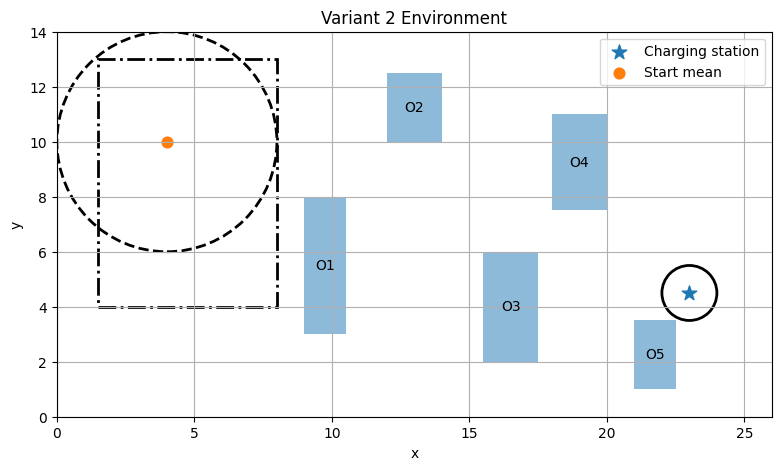

Environment map was plotted.


In [ ]:
# 导入画图组件
from matplotlib.patches import Rectangle, Circle, Ellipse

def plot_environment(config):
    # 读取地图大小
    width, height = config["space"]

    fig, ax = plt.subplots(figsize=(10, 5))

    # 设置地图范围
    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect("equal")

    # 画障碍物
    for i, obs in enumerate(config["obstacles"], start=1):
        x1, y1, x2, y2 = obs
        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            alpha=0.5
        )
        ax.add_patch(rect)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, f"O{i}", ha="center", va="center")

    # 画充电站
    station = config["station"]
    station_circle = Circle(
        station,
        config["station_radius"],
        fill=False,
        linewidth=2
    )
    ax.add_patch(station_circle)
    ax.scatter(station[0], station[1], marker="*", s=120, label="Charging station")

    # 画起点均值和 2σ 椭圆
    start_mean = config["start_mean"]
    sigma = config["start_sigma"]
    start_area = Ellipse(
        start_mean,
        width=4 * sigma,
        height=4 * sigma,
        fill=False,
        linestyle="--",
        linewidth=2
    )
    ax.add_patch(start_area)
    ax.scatter(start_mean[0], start_mean[1], marker="o", s=60, label="Start mean")

    # 画起点裁剪区域
    x_min, x_max = config["start_clip_x"]
    y_min, y_max = config["start_clip_y"]
    clip_rect = Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=False,
        linestyle="-.",
        linewidth=2
    )
    ax.add_patch(clip_rect)

    ax.set_title("Variant 2 Environment")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend()

    plt.show()

plot_environment(config)

print("Environment map was plotted.")

In [ ]:
class DroneEnv:
    def __init__(self, config, use_shaping=True):
        self.config = config
        self.use_shaping = use_shaping

        # 16 个离散动作：4 个方向 × 4 个速度
        self.directions = np.array([0, np.pi / 2, np.pi, 3 * np.pi / 2])
        self.speeds = config["speeds"]
        self.actions = [(theta, speed) for theta in self.directions for speed in self.speeds]
        self.n_actions = len(self.actions)

        self.reset()

    def sample_wind(self):
        # 随机生成风速
        wx = np.random.uniform(*self.config["wind_x"])
        wy = np.random.uniform(*self.config["wind_y"])
        return np.array([wx, wy])

    def in_station(self, pos):
        # 判断是否进入充电站范围
        distance = np.linalg.norm(pos - self.config["station"])
        return distance < self.config["station_radius"]

    def in_obstacle(self, pos):
        # 判断是否进入障碍物
        x, y = pos
        for x1, y1, x2, y2 in self.config["obstacles"]:
            if x1 <= x <= x2 and y1 <= y <= y2:
                return True
        return False

    def get_state(self):
        # 状态：相对位置、电量、速度
        dx, dy = self.config["station"] - self.pos
        return np.array([dx, dy, self.battery, self.speed])

    def reset(self):
        # 随机生成初始位置
        start = np.random.normal(
            loc=self.config["start_mean"],
            scale=self.config["start_sigma"],
            size=2
        )

        start[0] = np.clip(start[0], *self.config["start_clip_x"])
        start[1] = np.clip(start[1], *self.config["start_clip_y"])

        self.pos = start
        self.battery = 1.0
        self.speed = self.speeds[0]
        self.wind = self.sample_wind()
        self.step_count = 0
        self.collision_count = 0

        return self.get_state()

    def step(self, action_id):
        theta, target_speed = self.actions[action_id]
        self.speed = target_speed

        old_pos = self.pos.copy()
        old_distance = np.linalg.norm(old_pos - self.config["station"])

        # 按周期更新风
        if self.step_count > 0 and self.step_count % self.config["wind_update"] == 0:
            self.wind = self.sample_wind()

        wx, wy = self.wind

        # Variant 2 位置更新公式
        new_x = self.pos[0] + self.speed * np.cos(theta) + 0.8 * wx
        new_y = self.pos[1] + self.speed * np.sin(theta) + 1.2 * wy

        new_x = np.clip(new_x, 0, self.config["space"][0])
        new_y = np.clip(new_y, 0, self.config["space"][1])
        new_pos = np.array([new_x, new_y])

        collision = False

        # 碰撞处理：禁止进入障碍物
        if self.in_obstacle(new_pos):
            new_pos = old_pos
            collision = True
            self.collision_count += 1

        self.pos = new_pos
        new_distance = np.linalg.norm(self.pos - self.config["station"])
        station_flag = 1 if self.in_station(self.pos) else 0

        # Variant 2 电池更新公式
        battery_cost = 0.020 * self.speed ** 2 + 0.004 * abs(wx) + 0.003 * abs(wy)
        self.battery = min(
            1.0,
            self.battery - battery_cost + station_flag * self.config["charge_power"]
        )

        self.step_count += 1

        # 终止条件
        success = (
            self.in_station(self.pos)
            and self.battery > self.config["success_battery"]
            and self.step_count < self.config["success_step"]
        )

        battery_fail = self.battery < self.config["battery_fail"]
        timeout = self.step_count >= self.config["max_steps"]
        done = success or battery_fail or timeout

        # 原始奖励函数
        if success:
            reward = self.config["success_reward"]
        elif battery_fail:
            reward = self.config["fail_reward"]
        else:
            reward = -1.2 - 0.035 * self.speed ** 2 + 0.15 * self.config["charge_power"] * station_flag

            # 辅助奖励：靠近目标更好，碰撞更差
            if self.use_shaping:
                progress = old_distance - new_distance
                reward += 3.0 * progress

                if collision:
                    reward -= 2.0

        info = {
            "success": success,
            "battery_fail": battery_fail,
            "timeout": timeout,
            "collision": collision,
            "position": self.pos.copy(),
            "battery": self.battery,
            "wind": self.wind.copy()
        }

        return self.get_state(), reward, done, info


# 重新创建环境
env = DroneEnv(config, use_shaping=True)

state = env.reset()
print("Environment updated.")
print("Number of actions:", env.n_actions)
print("Initial state:", state)

next_state, reward, done, info = env.step(0)
print("Next state:", next_state)
print("Reward:", reward)
print("Done:", done)
print("Info:", info)

Environment updated.
Number of actions: 16
Initial state: [19.46830675 -5.03172609  1.          0.12      ]
Next state: [19.45147804 -5.14521425  0.99891242  0.12      ]
Reward: -1.2377904330999505
Done: False
Info: {'success': np.False_, 'battery_fail': np.False_, 'timeout': False, 'collision': False, 'position': array([3.54852196, 9.64521425]), 'battery': np.float64(0.9989124231421561), 'wind': array([-0.12896411,  0.09457347])}


In [ ]:
class StateDiscretizer:
    def __init__(self, config):
        self.config = config
        self.dx_bins, self.dy_bins, self.battery_bins, self.speed_bins = config["state_bins"]

        width, height = config["space"]
        sx, sy = config["station"]

        # 设置相对位置和电量的分箱边界
        self.dx_edges = np.linspace(sx - width, sx, self.dx_bins + 1)[1:-1]
        self.dy_edges = np.linspace(sy - height, sy, self.dy_bins + 1)[1:-1]
        self.battery_edges = np.linspace(0.0, 1.0, self.battery_bins + 1)[1:-1]

    def discretize(self, state):
        dx, dy, battery, speed = state

        # 把连续状态转成离散编号
        dx_id = np.digitize(dx, self.dx_edges)
        dy_id = np.digitize(dy, self.dy_edges)
        battery_id = np.digitize(battery, self.battery_edges)

        # 速度本身已经是离散集合
        speed_id = int(np.argmin(np.abs(self.config["speeds"] - speed)))

        return (dx_id, dy_id, battery_id, speed_id)


# 创建离散化工具
discretizer = StateDiscretizer(config)

# 创建 Q 表
q_shape = config["state_bins"] + (env.n_actions,)
Q = np.zeros(q_shape)

# 测试离散化结果
state = env.reset()
state_id = discretizer.discretize(state)

print("State discretizer created.")
print("Q-table shape:", Q.shape)
print("Continuous state:", state)
print("Discrete state:", state_id)
print("Initial Q values:", Q[state_id])

State discretizer created.
Q-table shape: (15, 15, 10, 4, 16)
Continuous state: [15.84157437 -7.03486946  1.          0.12      ]
Discrete state: (np.int64(10), np.int64(2), np.int64(9), 0)
Initial Q values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
class RationalQLearningAgent:
    def __init__(self, state_bins, n_actions, alpha=0.1, gamma=0.99):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma

        # 初始化 Q 表
        self.Q = np.zeros(state_bins + (n_actions,))

    def select_action(self, state_id, epsilon):
        # epsilon-greedy 选择动作
        if np.random.rand() < epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.Q[state_id])

    def update(self, state_id, action_id, reward, next_state_id, done):
        # 计算 Q-learning 的 TD 目标
        old_value = self.Q[state_id + (action_id,)]

        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.Q[next_state_id])

        # 更新 Q 值
        td_error = target - old_value
        self.Q[state_id + (action_id,)] = old_value + self.alpha * td_error

        return td_error


# 创建普通 Q-learning 智能体
rational_agent = RationalQLearningAgent(
    state_bins=config["state_bins"],
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=GAMMA
)

# 简单测试智能体是否能选择动作和更新 Q 表
state = env.reset()
state_id = discretizer.discretize(state)

action_id = rational_agent.select_action(state_id, epsilon=1.0)
next_state, reward, done, info = env.step(action_id)
next_state_id = discretizer.discretize(next_state)

td_error = rational_agent.update(
    state_id,
    action_id,
    reward,
    next_state_id,
    done
)

print("Rational Q-learning agent created.")
print("Selected action:", action_id)
print("Reward:", reward)
print("TD error:", td_error)
print("Updated Q value:", rational_agent.Q[state_id + (action_id,)])

Rational Q-learning agent created.
Selected action: 5
Reward: -1.6696230321292242
TD error: -1.6696230321292242
Updated Q value: -0.16696230321292244


In [ ]:
def train_agent(env, agent, discretizer, episodes,
                epsilon_start, epsilon_min, epsilon_decay,
                print_every=1000):

    logs = {
        "episode": [],
        "total_reward": [],
        "steps": [],
        "collisions": [],
        "final_battery": [],
        "success": []
    }

    epsilon = epsilon_start

    for ep in range(episodes):
        # 初始化当前 episode
        state = env.reset()
        state_id = discretizer.discretize(state)

        total_reward = 0
        done = False
        last_info = None

        while not done:
            # 选择动作并更新环境
            action_id = agent.select_action(state_id, epsilon)
            next_state, reward, done, info = env.step(action_id)
            next_state_id = discretizer.discretize(next_state)

            # 更新 Q 表
            agent.update(state_id, action_id, reward, next_state_id, done)

            state_id = next_state_id
            total_reward += reward
            last_info = info

        logs["episode"].append(ep + 1)
        logs["total_reward"].append(total_reward)
        logs["steps"].append(env.step_count)
        logs["collisions"].append(env.collision_count)
        logs["final_battery"].append(env.battery)
        logs["success"].append(int(last_info["success"]))

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (ep + 1) % print_every == 0:
            recent_success = np.mean(logs["success"][-print_every:]) * 100
            recent_reward = np.mean(logs["total_reward"][-print_every:])
            recent_steps = np.mean(logs["steps"][-print_every:])

            print(
                f"Episode {ep + 1}: "
                f"success={recent_success:.1f}%, "
                f"reward={recent_reward:.2f}, "
                f"steps={recent_steps:.1f}, "
                f"epsilon={epsilon:.3f}"
            )

    return pd.DataFrame(logs)


# 创建一个新的普通 Q-learning 智能体
rational_agent = RationalQLearningAgent(
    state_bins=config["state_bins"],
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=GAMMA
)

# 先用 300 轮测试训练流程
DEBUG_EPISODES = 300

print("Start debug training...")

rational_train_log = train_agent(
    env=env,
    agent=rational_agent,
    discretizer=discretizer,
    episodes=DEBUG_EPISODES,
    epsilon_start=EPS_START,
    epsilon_min=EPS_MIN,
    epsilon_decay=EPS_DECAY,
    print_every=1000
)

print("Debug training completed.")
print("Training log shape:", rational_train_log.shape)
print("Average success rate:", rational_train_log["success"].mean())
print("Average reward:", rational_train_log["total_reward"].mean())
print("Average steps:", rational_train_log["steps"].mean())

Start debug training...
Debug training completed.
Training log shape: (300, 6)
Average success rate: 0.01
Average reward: -275.16033603645184
Average steps: 204.54


In [ ]:
# 重新创建普通 Q-learning 智能体
rational_agent = RationalQLearningAgent(
    state_bins=config["state_bins"],
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=GAMMA
)

print("Start training rational agent...")

# 正式训练 15000 轮
rational_train_log = train_agent(
    env=env,
    agent=rational_agent,
    discretizer=discretizer,
    episodes=TRAIN_EPISODES,
    epsilon_start=EPS_START,
    epsilon_min=EPS_MIN,
    epsilon_decay=EPS_DECAY,
    print_every=1000
)

print("Rational agent training completed.")
print("Average success rate:", rational_train_log["success"].mean())
print("Average reward:", rational_train_log["total_reward"].mean())
print("Average steps:", rational_train_log["steps"].mean())

Start training rational agent...
Episode 1000: success=59.5%, reward=-76.84, steps=129.8, epsilon=0.050
Episode 2000: success=98.8%, reward=79.34, steps=62.0, epsilon=0.010
Episode 3000: success=99.8%, reward=84.85, steps=59.1, epsilon=0.010
Episode 4000: success=99.5%, reward=84.45, steps=58.7, epsilon=0.010
Episode 5000: success=99.5%, reward=83.39, steps=59.5, epsilon=0.010
Episode 6000: success=99.3%, reward=84.37, steps=59.2, epsilon=0.010
Episode 7000: success=99.4%, reward=83.00, steps=59.7, epsilon=0.010
Episode 8000: success=99.6%, reward=84.50, steps=59.0, epsilon=0.010
Episode 9000: success=99.7%, reward=85.47, steps=58.1, epsilon=0.010
Episode 10000: success=99.7%, reward=85.40, steps=58.6, epsilon=0.010
Episode 11000: success=99.5%, reward=83.52, steps=59.9, epsilon=0.010
Episode 12000: success=99.4%, reward=83.96, steps=59.4, epsilon=0.010
Episode 13000: success=99.8%, reward=84.12, steps=59.1, epsilon=0.010
Episode 14000: success=99.8%, reward=84.29, steps=58.9, epsilon=

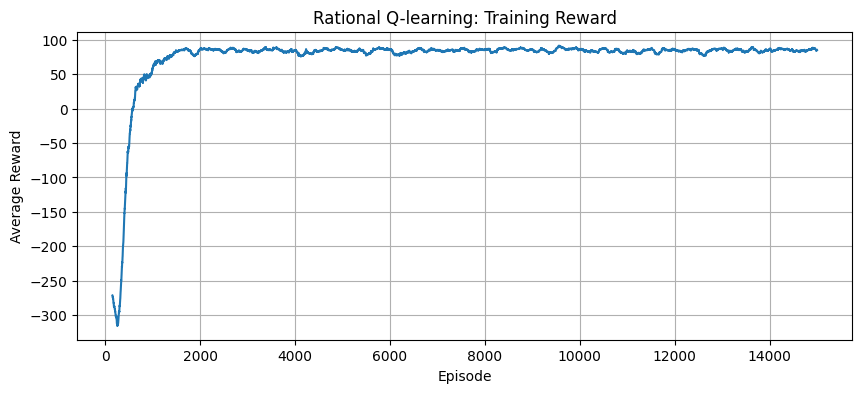

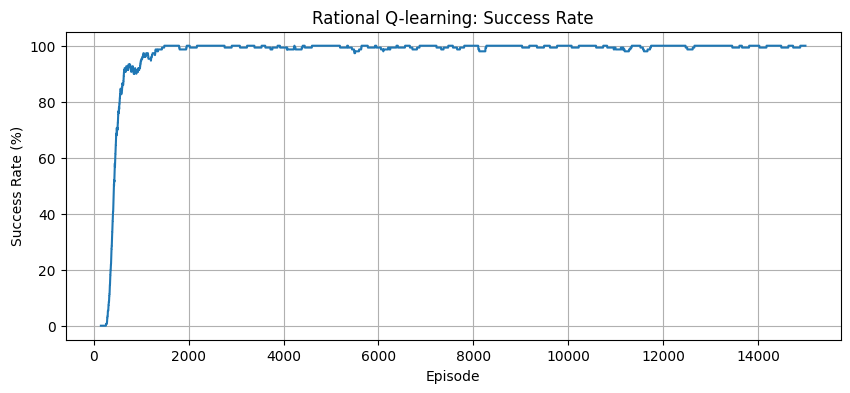

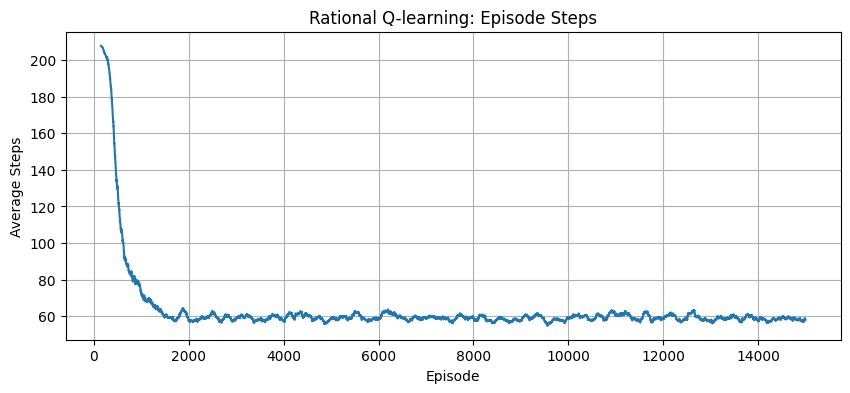

Learning curves were plotted.
Final 1000-episode success rate: 0.997
Final 1000-episode average reward: 84.87297758482119
Final 1000-episode average steps: 58.343


In [ ]:
# 设置滑动窗口
WINDOW = 150

# 计算滑动平均
rational_train_log["reward_smooth"] = rational_train_log["total_reward"].rolling(WINDOW).mean()
rational_train_log["success_smooth"] = rational_train_log["success"].rolling(WINDOW).mean() * 100
rational_train_log["steps_smooth"] = rational_train_log["steps"].rolling(WINDOW).mean()

# 画累计奖励学习曲线
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["reward_smooth"])
plt.title("Rational Q-learning: Training Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

# 画成功率变化曲线
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["success_smooth"])
plt.title("Rational Q-learning: Success Rate")
plt.xlabel("Episode")
plt.ylabel("Success Rate (%)")
plt.grid(True)
plt.show()

# 画平均步数变化曲线
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["steps_smooth"])
plt.title("Rational Q-learning: Episode Steps")
plt.xlabel("Episode")
plt.ylabel("Average Steps")
plt.grid(True)
plt.show()

print("Learning curves were plotted.")
print("Final 1000-episode success rate:", rational_train_log["success"].tail(1000).mean())
print("Final 1000-episode average reward:", rational_train_log["total_reward"].tail(1000).mean())
print("Final 1000-episode average steps:", rational_train_log["steps"].tail(1000).mean())

In [ ]:
class ProspectQLearningAgent(RationalQLearningAgent):
    def __init__(self, state_bins, n_actions, alpha=0.1, gamma=0.99,
                 alpha_p=0.88, beta_p=0.88, lambda_p=2.35):
        super().__init__(state_bins, n_actions, alpha, gamma)

        # Prospect Theory 参数
        self.alpha_p = alpha_p
        self.beta_p = beta_p
        self.lambda_p = lambda_p

    def value_function(self, reward):
        # 奖励转成主观价值
        if reward >= 0:
            return reward ** self.alpha_p
        else:
            return -self.lambda_p * ((-reward) ** self.beta_p)

    def update(self, state_id, action_id, reward, next_state_id, done):
        # 使用转换后的奖励更新 Q 表
        subjective_reward = self.value_function(reward)
        old_value = self.Q[state_id + (action_id,)]

        if done:
            target = subjective_reward
        else:
            target = subjective_reward + self.gamma * np.max(self.Q[next_state_id])

        td_error = target - old_value
        self.Q[state_id + (action_id,)] = old_value + self.alpha * td_error

        return td_error


# 创建行为型 Q-learning 智能体
prospect_agent = ProspectQLearningAgent(
    state_bins=config["state_bins"],
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=GAMMA,
    alpha_p=0.88,
    beta_p=0.88,
    lambda_p=2.35
)

# 简单测试奖励转换和 Q 表更新
state = env.reset()
state_id = discretizer.discretize(state)

action_id = prospect_agent.select_action(state_id, epsilon=1.0)
next_state, reward, done, info = env.step(action_id)
next_state_id = discretizer.discretize(next_state)

subjective_reward = prospect_agent.value_function(reward)

td_error = prospect_agent.update(
    state_id,
    action_id,
    reward,
    next_state_id,
    done
)

print("Prospect Theory Q-learning agent created.")
print("Original reward:", reward)
print("Subjective reward:", subjective_reward)
print("TD error:", td_error)
print("Updated Q value:", prospect_agent.Q[state_id + (action_id,)])

Prospect Theory Q-learning agent created.
Original reward: -1.5482852329931918
Subjective reward: -3.4525240882462596
TD error: -3.4525240882462596
Updated Q value: -0.345252408824626


In [ ]:
# 重新创建行为型 Q-learning 智能体
prospect_agent = ProspectQLearningAgent(
    state_bins=config["state_bins"],
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=GAMMA,
    alpha_p=0.88,
    beta_p=0.88,
    lambda_p=2.35
)

print("Start training prospect agent...")

# 正式训练 15000 轮
prospect_train_log = train_agent(
    env=env,
    agent=prospect_agent,
    discretizer=discretizer,
    episodes=TRAIN_EPISODES,
    epsilon_start=EPS_START,
    epsilon_min=EPS_MIN,
    epsilon_decay=EPS_DECAY,
    print_every=1000
)

print("Prospect agent training completed.")
print("Average success rate:", prospect_train_log["success"].mean())
print("Average reward:", prospect_train_log["total_reward"].mean())
print("Average steps:", prospect_train_log["steps"].mean())
print("Final 1000-episode success rate:", prospect_train_log["success"].tail(1000).mean())
print("Final 1000-episode average reward:", prospect_train_log["total_reward"].tail(1000).mean())
print("Final 1000-episode average steps:", prospect_train_log["steps"].tail(1000).mean())

Start training prospect agent...
Episode 1000: success=49.8%, reward=-116.68, steps=147.9, epsilon=0.050
Episode 2000: success=95.3%, reward=69.20, steps=67.4, epsilon=0.010
Episode 3000: success=98.6%, reward=88.24, steps=56.1, epsilon=0.010
Episode 4000: success=99.2%, reward=92.17, steps=53.6, epsilon=0.010
Episode 5000: success=99.2%, reward=92.29, steps=53.9, epsilon=0.010
Episode 6000: success=99.6%, reward=94.00, steps=53.0, epsilon=0.010
Episode 7000: success=99.2%, reward=92.24, steps=53.5, epsilon=0.010
Episode 8000: success=100.0%, reward=95.12, steps=52.3, epsilon=0.010
Episode 9000: success=99.7%, reward=93.77, steps=53.0, epsilon=0.010
Episode 10000: success=99.7%, reward=94.38, steps=52.5, epsilon=0.010
Episode 11000: success=100.0%, reward=95.03, steps=52.5, epsilon=0.010
Episode 12000: success=99.9%, reward=94.92, steps=52.4, epsilon=0.010
Episode 13000: success=100.0%, reward=94.61, steps=52.6, epsilon=0.010
Episode 14000: success=99.8%, reward=94.02, steps=52.8, epsi

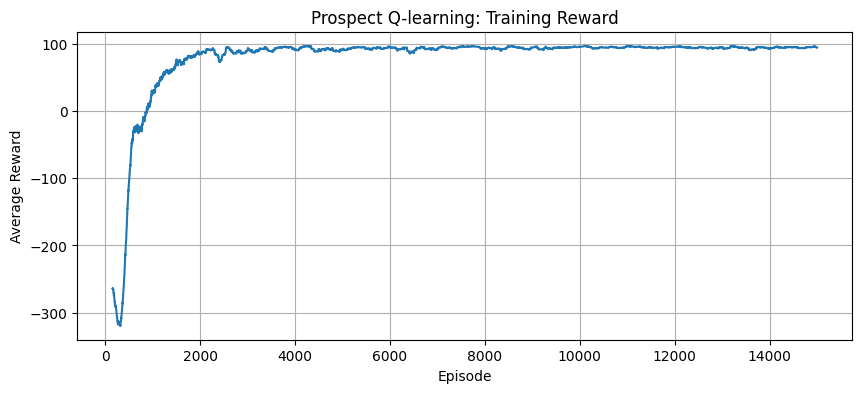

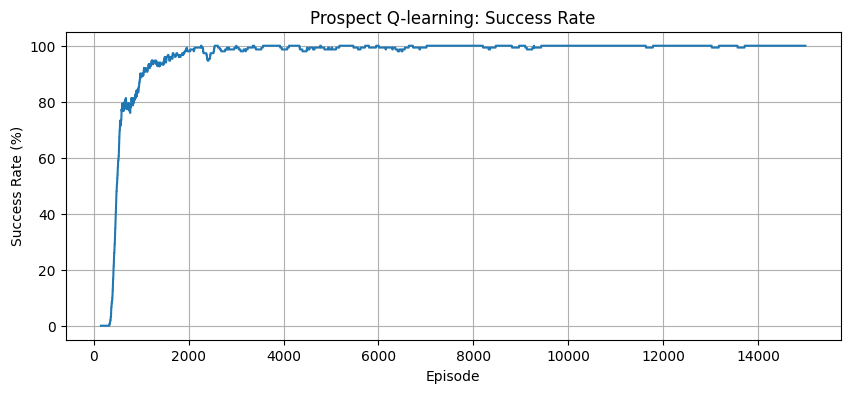

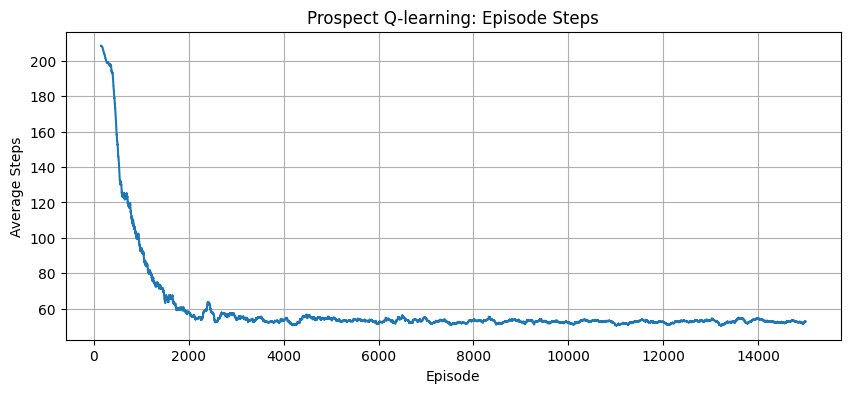

Prospect learning curves were plotted.
Final 1000-episode success rate: 1.0
Final 1000-episode average reward: 94.87142527093246
Final 1000-episode average steps: 52.535


In [ ]:
# 设置滑动窗口
WINDOW = 150

# 计算 Prospect agent 的滑动平均
prospect_train_log["reward_smooth"] = prospect_train_log["total_reward"].rolling(WINDOW).mean()
prospect_train_log["success_smooth"] = prospect_train_log["success"].rolling(WINDOW).mean() * 100
prospect_train_log["steps_smooth"] = prospect_train_log["steps"].rolling(WINDOW).mean()

# 画累计奖励学习曲线
plt.figure(figsize=(10, 4))
plt.plot(prospect_train_log["episode"], prospect_train_log["reward_smooth"])
plt.title("Prospect Q-learning: Training Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

# 画成功率曲线
plt.figure(figsize=(10, 4))
plt.plot(prospect_train_log["episode"], prospect_train_log["success_smooth"])
plt.title("Prospect Q-learning: Success Rate")
plt.xlabel("Episode")
plt.ylabel("Success Rate (%)")
plt.grid(True)
plt.show()

# 画平均步数曲线
plt.figure(figsize=(10, 4))
plt.plot(prospect_train_log["episode"], prospect_train_log["steps_smooth"])
plt.title("Prospect Q-learning: Episode Steps")
plt.xlabel("Episode")
plt.ylabel("Average Steps")
plt.grid(True)
plt.show()

print("Prospect learning curves were plotted.")
print("Final 1000-episode success rate:", prospect_train_log["success"].tail(1000).mean())
print("Final 1000-episode average reward:", prospect_train_log["total_reward"].tail(1000).mean())
print("Final 1000-episode average steps:", prospect_train_log["steps"].tail(1000).mean())

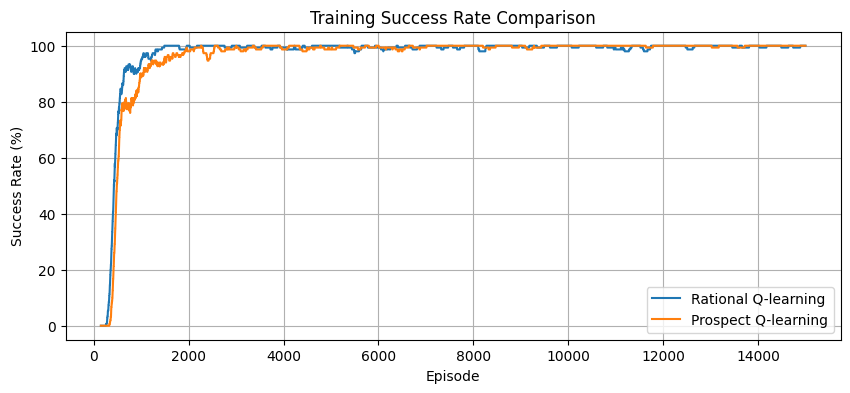

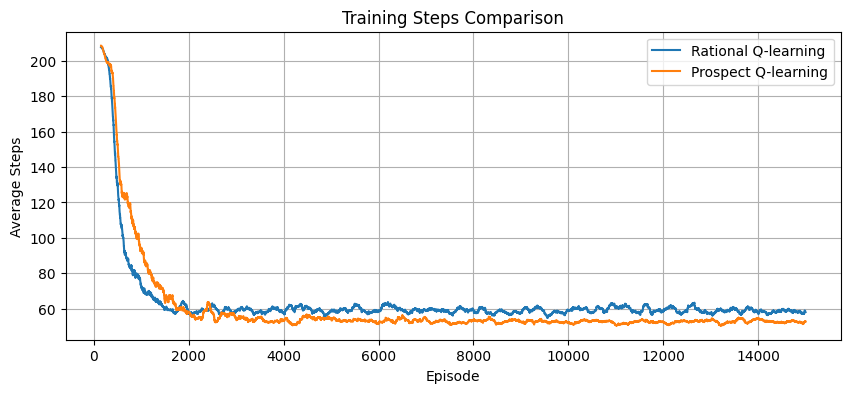

Comparison plots were created.


In [ ]:
# 对比两个智能体的成功率
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["success_smooth"], label="Rational Q-learning")
plt.plot(prospect_train_log["episode"], prospect_train_log["success_smooth"], label="Prospect Q-learning")
plt.title("Training Success Rate Comparison")
plt.xlabel("Episode")
plt.ylabel("Success Rate (%)")
plt.grid(True)
plt.legend()
plt.show()

# 对比两个智能体的平均步数
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["steps_smooth"], label="Rational Q-learning")
plt.plot(prospect_train_log["episode"], prospect_train_log["steps_smooth"], label="Prospect Q-learning")
plt.title("Training Steps Comparison")
plt.xlabel("Episode")
plt.ylabel("Average Steps")
plt.grid(True)
plt.legend()
plt.show()

print("Comparison plots were created.")

In [ ]:
class RiskSensitiveQLearningAgent(RationalQLearningAgent):
    def __init__(self, state_bins, n_actions, alpha=0.1, gamma=0.99,
                 eta=0.5, reward_scale=100.0):
        super().__init__(state_bins, n_actions, alpha, gamma)

        # 风险敏感参数
        self.eta = eta
        self.reward_scale = reward_scale

        # U 表用于指数效用更新
        self.U = np.ones(state_bins + (n_actions,))

    def update(self, state_id, action_id, reward, next_state_id, done):
        # 缩放奖励，避免指数计算过大
        r = reward / self.reward_scale

        old_u = self.U[state_id + (action_id,)]

        if done:
            target_u = np.exp(-self.eta * r)
        else:
            min_next_u = np.min(self.U[next_state_id])
            target_u = np.exp(-self.eta * r) * (min_next_u ** self.gamma)

        # 数值稳定处理
        target_u = np.clip(target_u, 1e-8, 1e8)

        # 更新 U 表
        new_u = (1 - self.alpha) * old_u + self.alpha * target_u
        new_u = np.clip(new_u, 1e-8, 1e8)
        self.U[state_id + (action_id,)] = new_u

        # 从 U 表转换回 Q 表
        new_q = -np.log(new_u) / self.eta
        self.Q[state_id + (action_id,)] = new_q

        td_error = new_q - self.Q[state_id + (action_id,)]
        return td_error


# 创建风险敏感型 Q-learning 智能体
risk_agent = RiskSensitiveQLearningAgent(
    state_bins=config["state_bins"],
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=GAMMA,
    eta=0.5,
    reward_scale=100.0
)

# 简单测试智能体是否可以更新
state = env.reset()
state_id = discretizer.discretize(state)

action_id = risk_agent.select_action(state_id, epsilon=1.0)
next_state, reward, done, info = env.step(action_id)
next_state_id = discretizer.discretize(next_state)

risk_agent.update(
    state_id,
    action_id,
    reward,
    next_state_id,
    done
)

print("Risk-sensitive Q-learning agent created.")
print("Selected eta:", risk_agent.eta)
print("Reward scale:", risk_agent.reward_scale)
print("Original reward:", reward)
print("Updated U value:", risk_agent.U[state_id + (action_id,)])
print("Updated Q value:", risk_agent.Q[state_id + (action_id,)])

Risk-sensitive Q-learning agent created.
Selected eta: 0.5
Reward scale: 100.0
Original reward: -1.8245845724717897
Updated U value: 1.0009164663558963
Updated Q value: -0.0018320933140250934


In [ ]:
# 重新创建风险敏感型 Q-learning 智能体
risk_agent = RiskSensitiveQLearningAgent(
    state_bins=config["state_bins"],
    n_actions=env.n_actions,
    alpha=0.1,
    gamma=GAMMA,
    eta=0.5,
    reward_scale=100.0
)

print("Start training risk-sensitive agent...")

# 正式训练 15000 轮
risk_train_log = train_agent(
    env=env,
    agent=risk_agent,
    discretizer=discretizer,
    episodes=TRAIN_EPISODES,
    epsilon_start=EPS_START,
    epsilon_min=EPS_MIN,
    epsilon_decay=EPS_DECAY,
    print_every=1000
)

print("Risk-sensitive agent training completed.")
print("Average success rate:", risk_train_log["success"].mean())
print("Average reward:", risk_train_log["total_reward"].mean())
print("Average steps:", risk_train_log["steps"].mean())
print("Final 1000-episode success rate:", risk_train_log["success"].tail(1000).mean())
print("Final 1000-episode average reward:", risk_train_log["total_reward"].tail(1000).mean())
print("Final 1000-episode average steps:", risk_train_log["steps"].tail(1000).mean())

Start training risk-sensitive agent...
Episode 1000: success=57.6%, reward=-77.35, steps=128.7, epsilon=0.050
Episode 2000: success=98.3%, reward=86.31, steps=56.7, epsilon=0.010
Episode 3000: success=99.7%, reward=91.44, steps=53.6, epsilon=0.010
Episode 4000: success=99.7%, reward=93.27, steps=52.8, epsilon=0.010
Episode 5000: success=100.0%, reward=93.84, steps=52.6, epsilon=0.010
Episode 6000: success=99.8%, reward=94.01, steps=52.5, epsilon=0.010
Episode 7000: success=99.8%, reward=92.39, steps=53.2, epsilon=0.010
Episode 8000: success=99.6%, reward=92.14, steps=53.1, epsilon=0.010
Episode 9000: success=100.0%, reward=94.06, steps=52.5, epsilon=0.010
Episode 10000: success=99.8%, reward=93.18, steps=53.0, epsilon=0.010
Episode 11000: success=99.9%, reward=93.76, steps=52.6, epsilon=0.010
Episode 12000: success=99.8%, reward=94.15, steps=52.3, epsilon=0.010
Episode 13000: success=99.9%, reward=93.65, steps=52.6, epsilon=0.010
Episode 14000: success=100.0%, reward=93.88, steps=52.5,

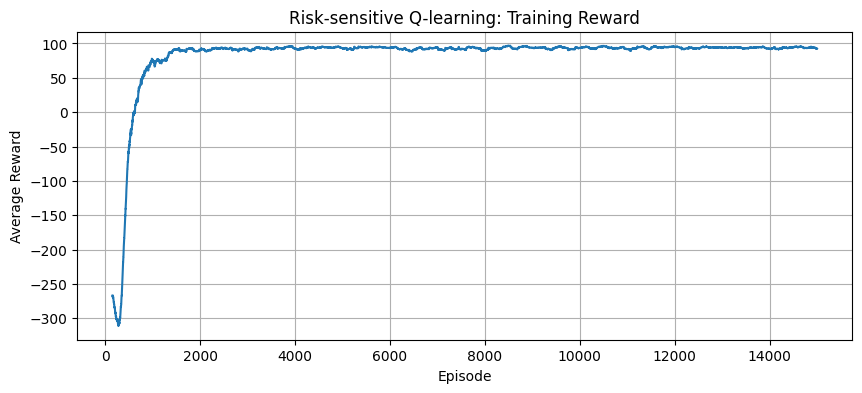

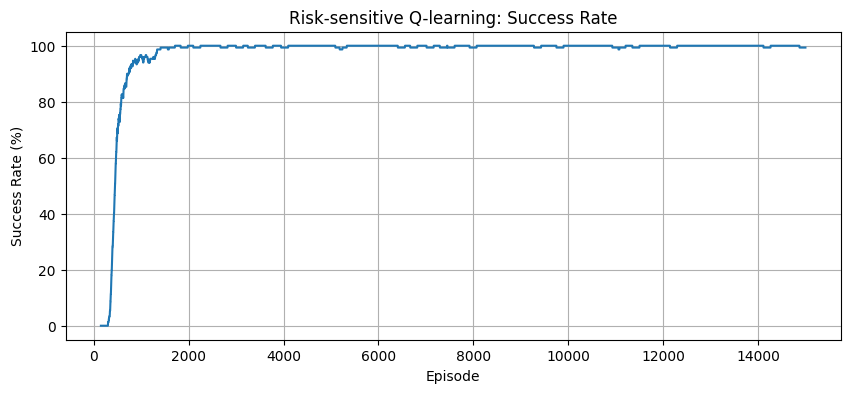

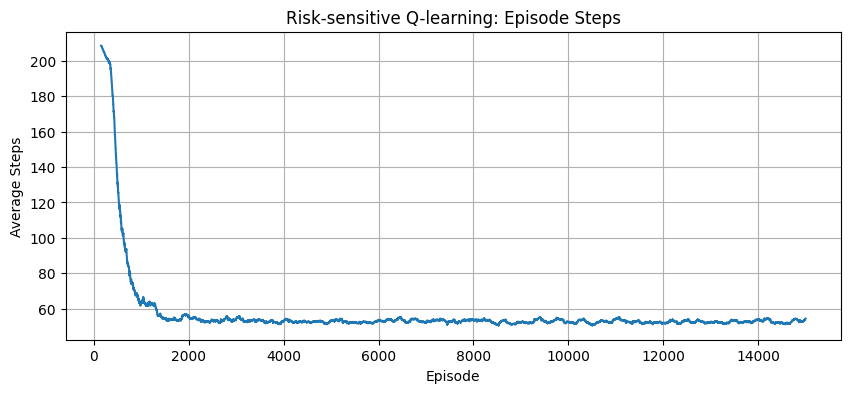

Risk-sensitive learning curves were plotted.


In [ ]:
# 设置滑动窗口
WINDOW = 150

# 计算 Risk-sensitive agent 的滑动平均
risk_train_log["reward_smooth"] = risk_train_log["total_reward"].rolling(WINDOW).mean()
risk_train_log["success_smooth"] = risk_train_log["success"].rolling(WINDOW).mean() * 100
risk_train_log["steps_smooth"] = risk_train_log["steps"].rolling(WINDOW).mean()

# 画 Risk-sensitive 的奖励曲线
plt.figure(figsize=(10, 4))
plt.plot(risk_train_log["episode"], risk_train_log["reward_smooth"])
plt.title("Risk-sensitive Q-learning: Training Reward")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

# 画 Risk-sensitive 的成功率曲线
plt.figure(figsize=(10, 4))
plt.plot(risk_train_log["episode"], risk_train_log["success_smooth"])
plt.title("Risk-sensitive Q-learning: Success Rate")
plt.xlabel("Episode")
plt.ylabel("Success Rate (%)")
plt.grid(True)
plt.show()

# 画 Risk-sensitive 的平均步数曲线
plt.figure(figsize=(10, 4))
plt.plot(risk_train_log["episode"], risk_train_log["steps_smooth"])
plt.title("Risk-sensitive Q-learning: Episode Steps")
plt.xlabel("Episode")
plt.ylabel("Average Steps")
plt.grid(True)
plt.show()

print("Risk-sensitive learning curves were plotted.")

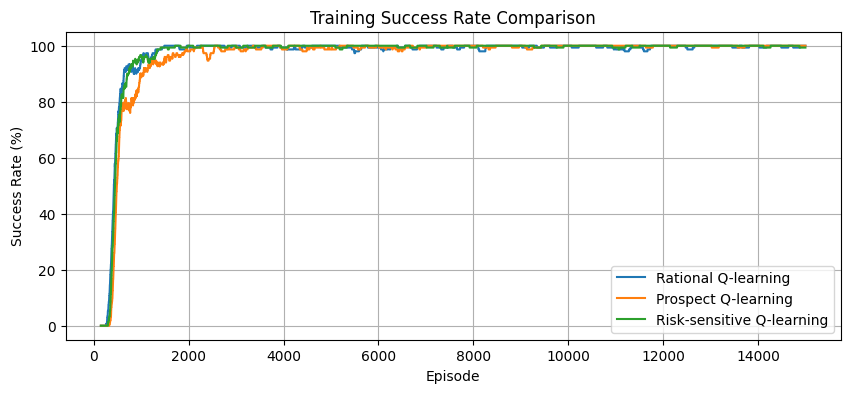

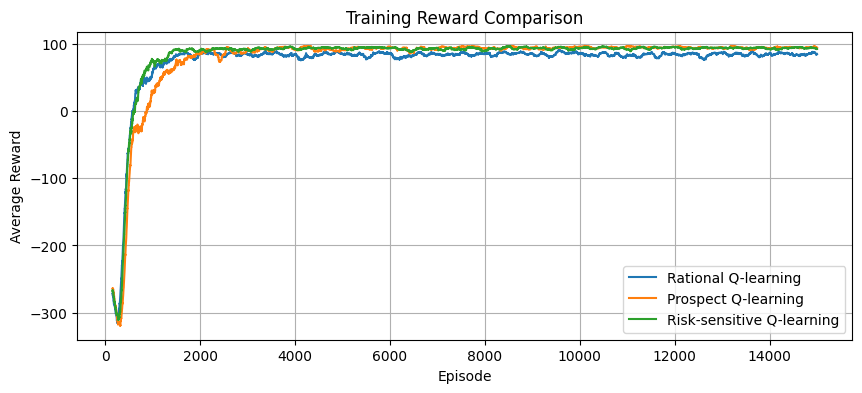

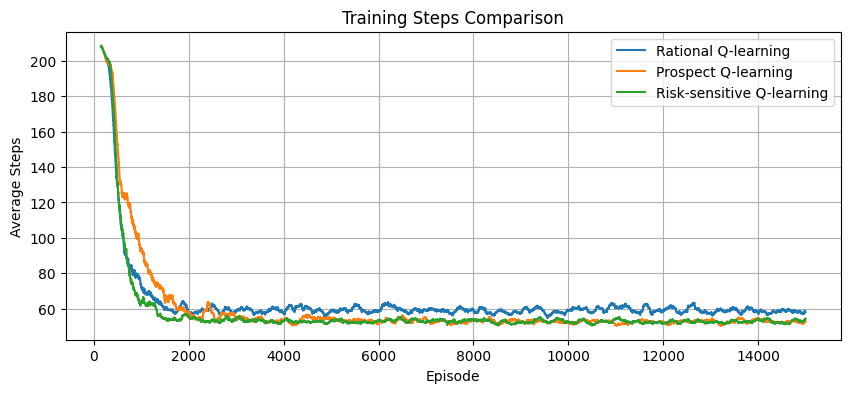

Training comparison plots were created.


In [ ]:
# 对比三个智能体的训练成功率
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["success_smooth"], label="Rational Q-learning")
plt.plot(prospect_train_log["episode"], prospect_train_log["success_smooth"], label="Prospect Q-learning")
plt.plot(risk_train_log["episode"], risk_train_log["success_smooth"], label="Risk-sensitive Q-learning")
plt.title("Training Success Rate Comparison")
plt.xlabel("Episode")
plt.ylabel("Success Rate (%)")
plt.grid(True)
plt.legend()
plt.show()

# 对比三个智能体的训练奖励
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["reward_smooth"], label="Rational Q-learning")
plt.plot(prospect_train_log["episode"], prospect_train_log["reward_smooth"], label="Prospect Q-learning")
plt.plot(risk_train_log["episode"], risk_train_log["reward_smooth"], label="Risk-sensitive Q-learning")
plt.title("Training Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.legend()
plt.show()

# 对比三个智能体的平均步数
plt.figure(figsize=(10, 4))
plt.plot(rational_train_log["episode"], rational_train_log["steps_smooth"], label="Rational Q-learning")
plt.plot(prospect_train_log["episode"], prospect_train_log["steps_smooth"], label="Prospect Q-learning")
plt.plot(risk_train_log["episode"], risk_train_log["steps_smooth"], label="Risk-sensitive Q-learning")
plt.title("Training Steps Comparison")
plt.xlabel("Episode")
plt.ylabel("Average Steps")
plt.grid(True)
plt.legend()
plt.show()

print("Training comparison plots were created.")

In [ ]:
# 汇总最后 1000 轮训练结果
training_summary = pd.DataFrame({
    "Agent": [
        "Rational Q-learning",
        "Prospect Q-learning",
        "Risk-sensitive Q-learning"
    ],
    "Final 1000 Success Rate": [
        rational_train_log["success"].tail(1000).mean(),
        prospect_train_log["success"].tail(1000).mean(),
        risk_train_log["success"].tail(1000).mean()
    ],
    "Final 1000 Average Reward": [
        rational_train_log["total_reward"].tail(1000).mean(),
        prospect_train_log["total_reward"].tail(1000).mean(),
        risk_train_log["total_reward"].tail(1000).mean()
    ],
    "Final 1000 Average Steps": [
        rational_train_log["steps"].tail(1000).mean(),
        prospect_train_log["steps"].tail(1000).mean(),
        risk_train_log["steps"].tail(1000).mean()
    ],
    "Final 1000 Average Collisions": [
        rational_train_log["collisions"].tail(1000).mean(),
        prospect_train_log["collisions"].tail(1000).mean(),
        risk_train_log["collisions"].tail(1000).mean()
    ],
    "Final 1000 Average Battery": [
        rational_train_log["final_battery"].tail(1000).mean(),
        prospect_train_log["final_battery"].tail(1000).mean(),
        risk_train_log["final_battery"].tail(1000).mean()
    ]
})

print("Training summary:")
display(training_summary)

Training summary:


,Agent,Final 1000 Success Rate,Final 1000 Average Reward,Final 1000 Average Steps,Final 1000 Average Collisions,Final 1000 Average Battery
0,Rational Q-learning,0.997,84.872978,58.343,1.233,0.893014
1,Prospect Q-learning,1.000,94.871425,52.535,0.198,0.893355
2,Risk-sensitive Q-learning,0.998,93.722324,52.901,0.716,0.894629


In [ ]:
def test_agent(env, agent, discretizer, episodes=300, epsilon=0.005):
    results = {
        "episode": [],
        "success": [],
        "steps": [],
        "energy_used": [],
        "collisions": [],
        "collision_episode": [],
        "final_battery": [],
        "total_reward": []
    }

    trajectories = []

    for ep in range(episodes):
        # 初始化测试 episode
        state = env.reset()
        state_id = discretizer.discretize(state)

        done = False
        total_reward = 0
        energy_used = 0
        trajectory = [env.pos.copy()]
        last_info = None

        while not done:
            # 测试时仍保留很小概率探索
            action_id = agent.select_action(state_id, epsilon)

            next_state, reward, done, info = env.step(action_id)
            next_state_id = discretizer.discretize(next_state)

            # 根据 Variant 2 的电池消耗公式统计能耗
            wx, wy = info["wind"]
            step_energy = 0.020 * env.speed ** 2 + 0.004 * abs(wx) + 0.003 * abs(wy)
            energy_used += step_energy

            state_id = next_state_id
            total_reward += reward
            trajectory.append(info["position"])
            last_info = info

        results["episode"].append(ep + 1)
        results["success"].append(int(last_info["success"]))
        results["steps"].append(env.step_count)
        results["energy_used"].append(energy_used)
        results["collisions"].append(env.collision_count)
        results["collision_episode"].append(int(env.collision_count > 0))
        results["final_battery"].append(env.battery)
        results["total_reward"].append(total_reward)

        trajectories.append(np.array(trajectory))

    return pd.DataFrame(results), trajectories


print("Start testing agents...")

rational_test_log, rational_trajectories = test_agent(
    env, rational_agent, discretizer,
    episodes=TEST_EPISODES,
    epsilon=TEST_EPS
)

prospect_test_log, prospect_trajectories = test_agent(
    env, prospect_agent, discretizer,
    episodes=TEST_EPISODES,
    epsilon=TEST_EPS
)

risk_test_log, risk_trajectories = test_agent(
    env, risk_agent, discretizer,
    episodes=TEST_EPISODES,
    epsilon=TEST_EPS
)

print("Testing completed.")
print("Rational test episodes:", rational_test_log.shape[0])
print("Prospect test episodes:", prospect_test_log.shape[0])
print("Risk-sensitive test episodes:", risk_test_log.shape[0])

Start testing agents...
Testing completed.
Rational test episodes: 300
Prospect test episodes: 300
Risk-sensitive test episodes: 300


In [ ]:
test_summary = pd.DataFrame({
    "Agent": [
        "Rational Q-learning",
        "Prospect Q-learning",
        "Risk-sensitive Q-learning"
    ],
    "Success Rate": [
        rational_test_log["success"].mean(),
        prospect_test_log["success"].mean(),
        risk_test_log["success"].mean()
    ],
    "Average Steps": [
        rational_test_log["steps"].mean(),
        prospect_test_log["steps"].mean(),
        risk_test_log["steps"].mean()
    ],
    "Average Energy Used": [
        rational_test_log["energy_used"].mean(),
        prospect_test_log["energy_used"].mean(),
        risk_test_log["energy_used"].mean()
    ],
    "Collision Episode Rate": [
        rational_test_log["collision_episode"].mean(),
        prospect_test_log["collision_episode"].mean(),
        risk_test_log["collision_episode"].mean()
    ],
    "Average Collisions": [
        rational_test_log["collisions"].mean(),
        prospect_test_log["collisions"].mean(),
        risk_test_log["collisions"].mean()
    ],
    "Average Final Battery": [
        rational_test_log["final_battery"].mean(),
        prospect_test_log["final_battery"].mean(),
        risk_test_log["final_battery"].mean()
    ]
})

print("Test summary:")
display(test_summary)

Test summary:


,Agent,Success Rate,Average Steps,Average Energy Used,Collision Episode Rate,Average Collisions,Average Final Battery
0,Rational Q-learning,1.0,58.090000,0.417146,0.196667,1.153333,0.892954
1,Prospect Q-learning,1.0,51.046667,0.391400,0.023333,0.073333,0.893500
2,Risk-sensitive Q-learning,1.0,52.473333,0.396521,0.150000,0.910000,0.895779


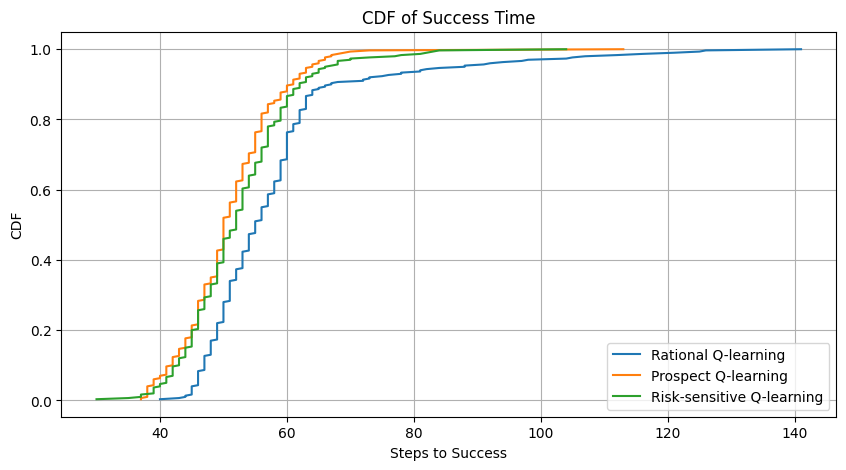

CDF plot was created.
Rational median steps: 55.0
Prospect median steps: 50.0
Risk-sensitive median steps: 52.0


In [ ]:
def plot_success_cdf(test_log, label):
    # 只统计成功的 episode
    success_steps = test_log[test_log["success"] == 1]["steps"].values
    success_steps = np.sort(success_steps)

    # 计算 CDF
    cdf = np.arange(1, len(success_steps) + 1) / len(success_steps)

    plt.plot(success_steps, cdf, label=label)
    return success_steps


plt.figure(figsize=(10, 5))

rational_success_steps = plot_success_cdf(rational_test_log, "Rational Q-learning")
prospect_success_steps = plot_success_cdf(prospect_test_log, "Prospect Q-learning")
risk_success_steps = plot_success_cdf(risk_test_log, "Risk-sensitive Q-learning")

plt.title("CDF of Success Time")
plt.xlabel("Steps to Success")
plt.ylabel("CDF")
plt.grid(True)
plt.legend()
plt.show()

print("CDF plot was created.")
print("Rational median steps:", np.median(rational_success_steps))
print("Prospect median steps:", np.median(prospect_success_steps))
print("Risk-sensitive median steps:", np.median(risk_success_steps))

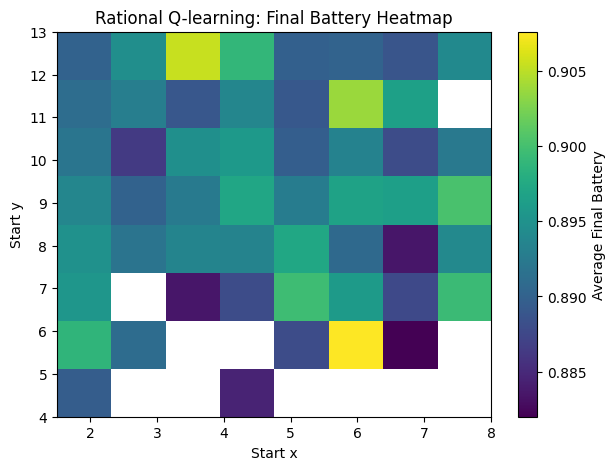

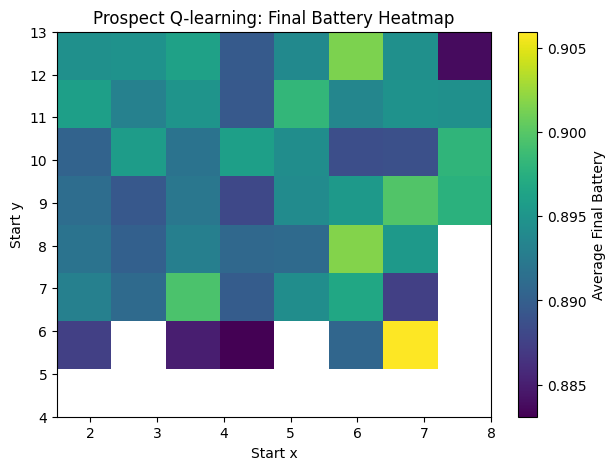

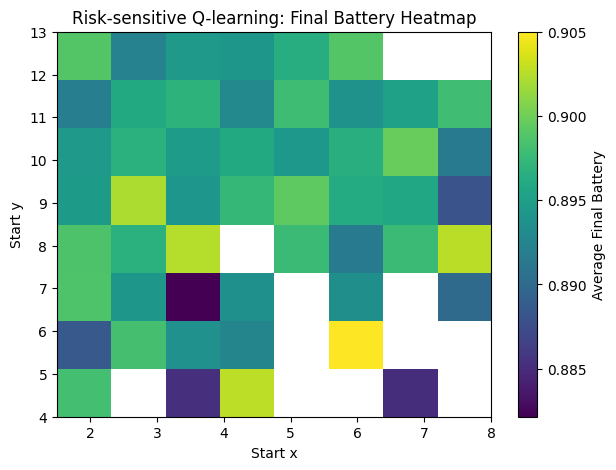

Final battery heatmaps were created.


In [ ]:
def plot_battery_heatmap(test_log, trajectories, title, bins=8):
    # 提取每个 episode 的起点和最终电量
    start_positions = np.array([traj[0] for traj in trajectories])
    final_battery = test_log["final_battery"].values

    x = start_positions[:, 0]
    y = start_positions[:, 1]

    # 建立二维网格
    x_edges = np.linspace(config["start_clip_x"][0], config["start_clip_x"][1], bins + 1)
    y_edges = np.linspace(config["start_clip_y"][0], config["start_clip_y"][1], bins + 1)

    heatmap = np.full((bins, bins), np.nan)

    # 计算每个起点区域的平均最终电量
    for i in range(bins):
        for j in range(bins):
            mask = (
                (x >= x_edges[j]) & (x < x_edges[j + 1]) &
                (y >= y_edges[i]) & (y < y_edges[i + 1])
            )
            if np.sum(mask) > 0:
                heatmap[i, j] = np.mean(final_battery[mask])

    # 画 heatmap
    plt.figure(figsize=(7, 5))
    plt.imshow(
        heatmap,
        origin="lower",
        extent=[
            config["start_clip_x"][0],
            config["start_clip_x"][1],
            config["start_clip_y"][0],
            config["start_clip_y"][1]
        ],
        aspect="auto"
    )
    plt.colorbar(label="Average Final Battery")
    plt.title(title)
    plt.xlabel("Start x")
    plt.ylabel("Start y")
    plt.grid(False)
    plt.show()


# 分别画三个智能体的最终电量 heatmap
plot_battery_heatmap(
    rational_test_log,
    rational_trajectories,
    "Rational Q-learning: Final Battery Heatmap"
)

plot_battery_heatmap(
    prospect_test_log,
    prospect_trajectories,
    "Prospect Q-learning: Final Battery Heatmap"
)

plot_battery_heatmap(
    risk_test_log,
    risk_trajectories,
    "Risk-sensitive Q-learning: Final Battery Heatmap"
)

print("Final battery heatmaps were created.")

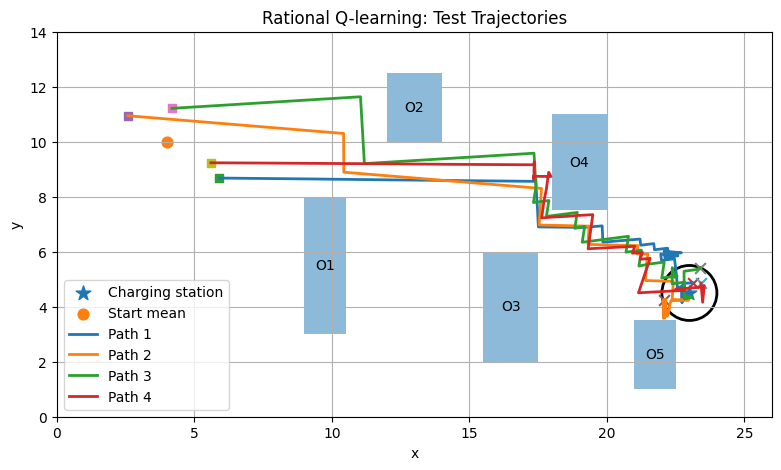

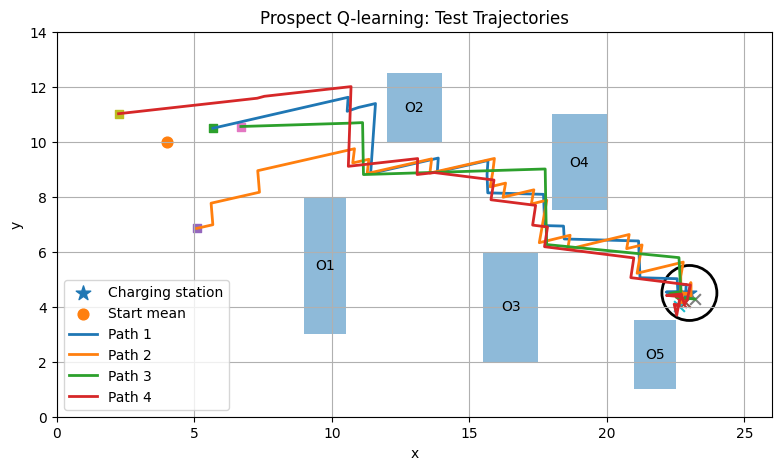

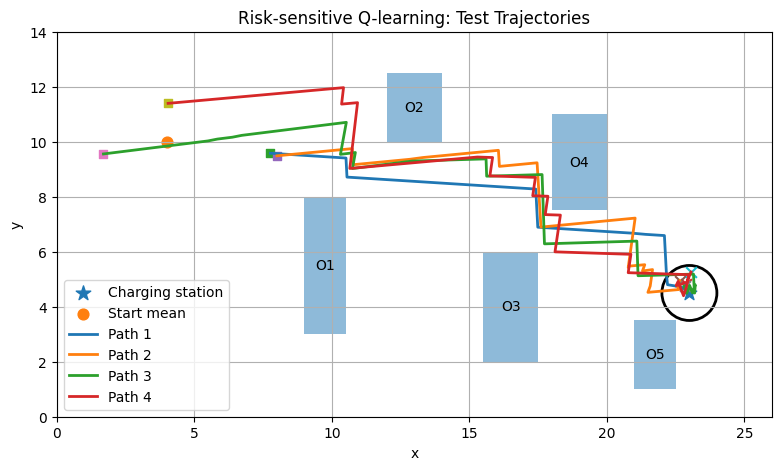

Trajectory plots were created.


In [ ]:
from matplotlib.patches import Rectangle, Circle

def plot_agent_trajectories(trajectories, title, n_paths=4):
    width, height = config["space"]

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    # 设置地图范围
    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect("equal")

    # 画障碍物
    for i, obs in enumerate(config["obstacles"], start=1):
        x1, y1, x2, y2 = obs
        rect = Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            alpha=0.5
        )
        ax.add_patch(rect)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, f"O{i}", ha="center", va="center")

    # 画充电站
    station = config["station"]
    circle = Circle(
        station,
        config["station_radius"],
        fill=False,
        linewidth=2
    )
    ax.add_patch(circle)
    ax.scatter(station[0], station[1], marker="*", s=120, label="Charging station")

    # 画起点均值
    start_mean = config["start_mean"]
    ax.scatter(start_mean[0], start_mean[1], marker="o", s=60, label="Start mean")

    # 画前 n_paths 条轨迹
    for i in range(n_paths):
        traj = trajectories[i]
        ax.plot(traj[:, 0], traj[:, 1], linewidth=2, label=f"Path {i + 1}")
        ax.scatter(traj[0, 0], traj[0, 1], marker="s", s=40)
        ax.scatter(traj[-1, 0], traj[-1, 1], marker="x", s=60)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend()
    plt.show()


# 每个智能体画 4 条轨迹
plot_agent_trajectories(
    rational_trajectories,
    "Rational Q-learning: Test Trajectories",
    n_paths=4
)

plot_agent_trajectories(
    prospect_trajectories,
    "Prospect Q-learning: Test Trajectories",
    n_paths=4
)

plot_agent_trajectories(
    risk_trajectories,
    "Risk-sensitive Q-learning: Test Trajectories",
    n_paths=4
)

print("Trajectory plots were created.")

In [ ]:
def run_ttest(data1, data2, name1, name2, metric):
    # 使用 Welch t-test，不假设两个样本方差相同
    t_stat, p_value = stats.ttest_ind(data1, data2, equal_var=False)

    return {
        "Metric": metric,
        "Comparison": f"{name1} vs {name2}",
        "Mean 1": np.mean(data1),
        "Mean 2": np.mean(data2),
        "t-statistic": t_stat,
        "p-value": p_value,
        "Significant": p_value < 0.05
    }


# 只使用成功 episode 的数据
rational_success = rational_test_log[rational_test_log["success"] == 1]
prospect_success = prospect_test_log[prospect_test_log["success"] == 1]
risk_success = risk_test_log[risk_test_log["success"] == 1]

ttest_results = []

# 对 steps 做 t-test
ttest_results.append(run_ttest(
    rational_success["steps"],
    prospect_success["steps"],
    "Rational",
    "Prospect",
    "Steps"
))

ttest_results.append(run_ttest(
    rational_success["steps"],
    risk_success["steps"],
    "Rational",
    "Risk-sensitive",
    "Steps"
))

ttest_results.append(run_ttest(
    prospect_success["steps"],
    risk_success["steps"],
    "Prospect",
    "Risk-sensitive",
    "Steps"
))

# 对 energy used 做 t-test
ttest_results.append(run_ttest(
    rational_success["energy_used"],
    prospect_success["energy_used"],
    "Rational",
    "Prospect",
    "Energy Used"
))

ttest_results.append(run_ttest(
    rational_success["energy_used"],
    risk_success["energy_used"],
    "Rational",
    "Risk-sensitive",
    "Energy Used"
))

ttest_results.append(run_ttest(
    prospect_success["energy_used"],
    risk_success["energy_used"],
    "Prospect",
    "Risk-sensitive",
    "Energy Used"
))

ttest_table = pd.DataFrame(ttest_results)

print("T-test results:")
display(ttest_table)

T-test results:


,Metric,Comparison,Mean 1,Mean 2,t-statistic,p-value,Significant
0,Steps,Rational vs Prospect,58.090000,51.046667,7.584905,1.790491e-13,True
1,Steps,Rational vs Risk-sensitive,58.090000,52.473333,5.883171,7.359303e-09,True
2,Steps,Prospect vs Risk-sensitive,51.046667,52.473333,-2.095241,3.657428e-02,True
3,Energy Used,Rational vs Prospect,0.417146,0.391400,4.796385,2.050121e-06,True
4,Energy Used,Rational vs Risk-sensitive,0.417146,0.396521,3.839541,1.366329e-04,True
5,Energy Used,Prospect vs Risk-sensitive,0.391400,0.396521,-1.022516,3.069500e-01,False


In [ ]:
# 保存实验结果表格
from google.colab import files

# 整理 t-test 表格
clean_ttest_table = ttest_table.copy()

clean_ttest_table = clean_ttest_table.rename(columns={
    "Comparison": "Compare",
    "t-statistic": "t",
    "p-value": "p",
    "Significant": "p < 0.05"
})

clean_ttest_table["Mean 1"] = clean_ttest_table["Mean 1"].round(4)
clean_ttest_table["Mean 2"] = clean_ttest_table["Mean 2"].round(4)
clean_ttest_table["t"] = clean_ttest_table["t"].round(4)
clean_ttest_table["p"] = clean_ttest_table["p"].apply(lambda x: f"{x:.4e}")

# 保存到一个 Excel 文件
file_name = "drone_rl_results_summary.xlsx"

with pd.ExcelWriter(file_name) as writer:
    training_summary.to_excel(writer, sheet_name="Training Summary", index=False)
    test_summary.to_excel(writer, sheet_name="Test Summary", index=False)
    clean_ttest_table.to_excel(writer, sheet_name="T-test Results", index=False)

print("Excel file saved:", file_name)

# 下载文件
files.download(file_name)

Excel file saved: drone_rl_results_summary.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>